# Phase 3 — Building Models with `torch.nn`

Phase 2 ended with a preview: `nn.Linear` + `optim.SGD` replacing our manual
`w` and manual gradient-descent update. This phase goes one level deeper —
how `nn.Module` actually works, how to build custom models, the standard
training-loop pattern, loss functions, optimizers, saving/loading, and
`Dataset`/`DataLoader` for batching. Everything here is what the MNIST
classifier in `phase3_project.ipynb` is built from.

| Term | Meaning |
|---|---|
| `nn.Parameter` | a tensor that auto-registers itself as learnable when assigned to a `Module` |
| `nn.Module` | base class for models/layers; tracks its parameters and submodules automatically |
| `nn.Linear` | a ready-made `y = xW^T + b` layer |
| `nn.Sequential` | chains layers into one callable model |
| loss function | measures how wrong a prediction is (`nn.MSELoss`, `nn.CrossEntropyLoss`, ...) |
| optimizer | applies the update rule using gradients (`optim.SGD`, `optim.Adam`, ...) |
| `Dataset` / `DataLoader` | define one sample / yield shuffled mini-batches |
| `state_dict` | a model's learnable tensors, as a name -> tensor mapping, for saving/loading |

## Roadmap for this notebook
```
nn.Parameter -> custom nn.Module -> nn.Linear & nn.Sequential & activations
    -> loss functions -> optimizers (SGD vs Adam) -> the training loop
    -> train() vs eval() -> saving & loading -> Dataset & DataLoader
```


## Section 1 — `nn.Parameter`: the Building Block

A plain tensor with `requires_grad=True` is trainable, but `nn.Module` has
no way to know it exists unless it's wrapped in `nn.Parameter` and assigned
as an attribute. This is *exactly* the bug that breaks a naive custom model:
if nothing is an `nn.Parameter` (or a submodule that contains one),
`model.parameters()` returns an **empty list**, and the optimizer has
nothing to update.

In [1]:
import torch
import torch.nn as nn

torch.manual_seed(42)

# A plain tensor with requires_grad=True works fine with autograd on its own...
w_plain = torch.tensor(0.0, requires_grad=True)
print(f'plain tensor requires_grad : {w_plain.requires_grad}')

# ...but nn.Parameter is what nn.Module looks for when it collects
# "everything this model needs to learn" via .parameters().
w_param = nn.Parameter(torch.tensor(0.0))
print(f'nn.Parameter requires_grad : {w_param.requires_grad}   <- True automatically')
print(f'type                       : {type(w_param)}')

plain tensor requires_grad : True
nn.Parameter requires_grad : True   <- True automatically
type                       : <class 'torch.nn.parameter.Parameter'>


## Section 2 — Building a Custom Model with `nn.Module`

Every custom model follows the same shape:
- `__init__`: create layers/parameters and assign them as `self.xxx` — this is what makes `nn.Module` able to find them
- `forward`: define how input flows through those layers to produce output

`nn.Module.__repr__` and `.parameters()` both walk this attribute tree
automatically, which is why *assigning as an attribute* (not just creating
a local variable) is what matters.

In [2]:
class ManualLinear(nn.Module):
    def __init__(self):
        super().__init__()
        self.w = nn.Parameter(torch.tensor(0.0))   # assigned as an attribute -> tracked
        self.b = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        return self.w * x + self.b

model = ManualLinear()
print(f'model.w = {model.w.item()}, model.b = {model.b.item()}')

print('\nlist(model.parameters()):')
for p in model.parameters():
    print(f'  {p}  requires_grad={p.requires_grad}')

# nn.Module also gives you a clean, structured printout for free
print(f'\nmodel:\n{model}')

model.w = 0.0, model.b = 0.0

list(model.parameters()):
  Parameter containing:
tensor(0., requires_grad=True)  requires_grad=True
  Parameter containing:
tensor(0., requires_grad=True)  requires_grad=True

model:
ManualLinear()


## Section 3 — `nn.Linear` & `nn.Sequential`: Built-in Layers

Hand-writing `w * x + b` doesn't scale to multiple input/output features.
`nn.Linear(in_features, out_features)` does the same job, generalized to
matrices, with proper weight initialization built in. `nn.Sequential`
chains several layers into a single callable model — the common shape for a
simple feed-forward network.

In [3]:
linear = nn.Linear(in_features=3, out_features=1)
print('=== nn.Linear(3, 1) ===')
print(f'weight shape: {linear.weight.shape}   <- (out_features, in_features)')
print(f'bias shape  : {linear.bias.shape}')
print(f'weight: {linear.weight}')
print(f'bias  : {linear.bias}')

x = torch.tensor([[1.0, 2.0, 3.0]])   # 1 sample, 3 features
print(f'\ninput x shape : {x.shape}')
print(f'output shape  : {linear(x).shape}   <- (batch, out_features)')

# ── ACTIVATION FUNCTIONS ──────────────────────────────────────────────────────
# Without a non-linear activation between layers, stacking Linear layers
# collapses mathematically into a single Linear layer. Activations are what
# let a network learn non-linear patterns.
relu = nn.ReLU()
sample = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0])
print(f'\nReLU({sample}) = {relu(sample)}   <- clamps negative values to 0')

# ── nn.SEQUENTIAL — chain layers into one callable model ─────────────────────
mlp = nn.Sequential(
    nn.Linear(4, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
)
print(f'\nmlp:\n{mlp}')

batch = torch.rand(5, 4)   # batch of 5 samples, 4 features each
print(f'\nmlp(batch of 5x4).shape: {mlp(batch).shape}   <- (5, 1)')

=== nn.Linear(3, 1) ===
weight shape: torch.Size([1, 3])   <- (out_features, in_features)
bias shape  : torch.Size([1])
weight: Parameter containing:
tensor([[ 0.4414,  0.4792, -0.1353]], requires_grad=True)
bias  : Parameter containing:
tensor([0.5304], requires_grad=True)

input x shape : torch.Size([1, 3])
output shape  : torch.Size([1, 1])   <- (batch, out_features)

ReLU(tensor([-2.0000, -0.5000,  0.0000,  0.5000,  2.0000])) = tensor([0.0000, 0.0000, 0.0000, 0.5000, 2.0000])   <- clamps negative values to 0

mlp:
Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)

mlp(batch of 5x4).shape: torch.Size([5, 1])   <- (5, 1)


## Section 4 — Loss Functions

- **`nn.MSELoss`** — regression: penalizes the squared difference between prediction and target.
- **`nn.CrossEntropyLoss`** — multi-class classification: expects **raw logits** (no softmax applied) plus integer class labels. It applies log-softmax + negative-log-likelihood internally, so passing already-softmaxed probabilities double-applies softmax and silently produces a worse-trained model.

In [4]:
# ── REGRESSION — Mean Squared Error ───────────────────────────────────────────
mse = nn.MSELoss()
pred = torch.tensor([2.5, 3.0, 5.0])
true = torch.tensor([3.0, 3.0, 4.0])
print(f'MSELoss: {mse(pred, true).item():.4f}')

# ── CLASSIFICATION — Cross Entropy ────────────────────────────────────────────
ce = nn.CrossEntropyLoss()
logits = torch.tensor([[2.0, 0.5, 0.1],     # sample 1: model is confident in class 0
                        [0.1, 0.2, 3.0]])   # sample 2: model is confident in class 2
labels = torch.tensor([0, 2])                # true classes
print(f'CrossEntropyLoss (correct labels): {ce(logits, labels).item():.4f}')

# A confident WRONG prediction should produce a much higher loss:
wrong_labels = torch.tensor([2, 0])
print(f'CrossEntropyLoss (wrong labels)  : {ce(logits, wrong_labels).item():.4f}   <- much higher')

MSELoss: 0.4167
CrossEntropyLoss (correct labels): 0.2132
CrossEntropyLoss (wrong labels)  : 2.6132   <- much higher


## Section 5 — Optimizers: SGD vs Adam

The optimizer applies the update rule using the gradients autograd already
computed — it replaces the manual `with torch.no_grad(): w -= lr * w.grad`
from Phase 2.

- **`optim.SGD`** — the plain update rule: `param -= lr * grad`. One fixed step size, directly proportional to however large the raw gradient happens to be.
- **`optim.Adam`** — keeps running estimates of each parameter's gradient mean and variance, and normalizes by them. This makes its step size roughly `lr` regardless of how big the raw gradient is — a deliberate trade-off, not a strictly "better" one. It tends to win on noisy, high-dimensional, non-convex problems (like the MNIST classifier next), but on a tiny, well-scaled, convex toy problem, a large raw gradient can let plain SGD move faster in the same number of steps. Let's measure both instead of assuming.

In [5]:
import torch.optim as optim

def train_tiny_model(optimizer_cls, lr, steps=30):
    torch.manual_seed(0)
    model = nn.Linear(1, 1)
    x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
    y = torch.tensor([[2.0], [4.0], [6.0], [8.0]])
    optimizer = optimizer_cls(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for _ in range(steps):
        optimizer.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        optimizer.step()
    return loss.item()

sgd_loss = train_tiny_model(optim.SGD, lr=0.01)
adam_loss = train_tiny_model(optim.Adam, lr=0.01)

print('Final loss after 30 steps on the same problem, same learning rate:')
print(f'  SGD  : {sgd_loss:.5f}')
print(f'  Adam : {adam_loss:.5f}')
print('\nSGD actually wins here -- the raw gradient starts large (loss starts high),')
print('so its unnormalized step covers a lot of ground fast. Adam intentionally')
print('caps its step size near lr, so it needs more steps to catch up on a problem')
print('this simple. Neither optimizer is "just better" -- they make different')
print('trade-offs, and the right choice depends on the problem.')

Final loss after 30 steps on the same problem, same learning rate:
  SGD  : 0.16824
  Adam : 15.87001

SGD actually wins here -- the raw gradient starts large (loss starts high),
so its unnormalized step covers a lot of ground fast. Adam intentionally
caps its step size near lr, so it needs more steps to catch up on a problem
this simple. Neither optimizer is "just better" -- they make different
trade-offs, and the right choice depends on the problem.


## Section 6 — The Standard Training Loop

Every PyTorch training loop follows the same 5 steps:

```
optimizer.zero_grad()      # clear gradients from the previous step
y_pred = model(x)          # forward pass
loss = loss_fn(y_pred, y)  # how wrong are we?
loss.backward()            # backward pass -- fills in .grad for every parameter
optimizer.step()           # apply the update rule
```

This time, a fully working custom model — `nn.Linear` registers its weight
and bias as `nn.Parameter`s automatically, so `model.parameters()` is never
empty.

Epoch  10, Loss: 0.4992
Epoch  20, Loss: 0.6244
Epoch  30, Loss: 0.3739
Epoch  40, Loss: 0.1655
Epoch  50, Loss: 0.1264
Epoch  60, Loss: 0.0778
Epoch  70, Loss: 0.0420
Epoch  80, Loss: 0.0227
Epoch  90, Loss: 0.0120
Epoch 100, Loss: 0.0059

Learned: y = 1.940x + 0.180   (true relationship: y = 2x)


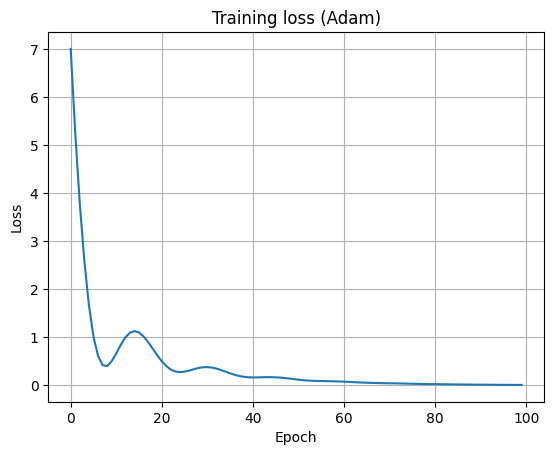

In [6]:
import matplotlib.pyplot as plt

class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)   # 1 input feature -> 1 output

    def forward(self, x):
        return self.linear(x)

x = torch.tensor([[1.], [2.], [3.], [4.]])
y = torch.tensor([[2.], [4.], [6.], [8.]])

torch.manual_seed(42)   # reseed locally so this cell's result is reproducible on its own
model = LinearModel()
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

loss_history = []
for epoch in range(100):
    optimizer.zero_grad()
    y_pred = model(x)
    loss = loss_fn(y_pred, y)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1:3d}, Loss: {loss.item():.4f}')

w = model.linear.weight.item()
b = model.linear.bias.item()
print(f'\nLearned: y = {w:.3f}x + {b:.3f}   (true relationship: y = 2x)')

plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss (Adam)')
plt.grid(True)
plt.show()

## Section 7 — `model.train()` vs `model.eval()`

Some layers behave differently while training vs while being evaluated —
`nn.Dropout` randomly zeroes activations during training (as regularization)
but must be fully "on" (no randomness) during evaluation, and `nn.BatchNorm`
uses batch statistics while training but running averages at eval time.
Our simple models don't use those layers yet, but the MNIST project does
call `.train()` / `.eval()`, so it's worth seeing why that matters now,
with `nn.Dropout` as a visible example.

In [7]:
torch.manual_seed(1)
dropout_demo = nn.Sequential(nn.Linear(4, 4), nn.Dropout(p=0.5))
sample = torch.ones(1, 4)

dropout_demo.train()   # training mode: dropout randomly zeroes ~50% of activations
print('train() mode, 3 runs (randomness expected):')
for _ in range(3):
    print(dropout_demo(sample))

dropout_demo.eval()    # eval mode: dropout is disabled, output is deterministic
print('\neval() mode, 3 runs (should be identical):')
for _ in range(3):
    print(dropout_demo(sample))

train() mode, 3 runs (randomness expected):
tensor([[ 0.0000, -0.0427,  0.0000,  0.1238]], grad_fn=<MulBackward0>)
tensor([[ 0.4943, -0.0427,  0.0000,  0.1238]], grad_fn=<MulBackward0>)
tensor([[0., -0., 0., 0.]], grad_fn=<MulBackward0>)

eval() mode, 3 runs (should be identical):
tensor([[ 0.2472, -0.0213,  0.6087,  0.0619]], grad_fn=<AddmmBackward0>)
tensor([[ 0.2472, -0.0213,  0.6087,  0.0619]], grad_fn=<AddmmBackward0>)
tensor([[ 0.2472, -0.0213,  0.6087,  0.0619]], grad_fn=<AddmmBackward0>)


## Section 8 — Saving & Loading Models

A model's `state_dict()` is an ordered mapping of parameter name -> tensor.
The recommended pattern is to save **just the state_dict** (not the whole
model object), then reload it into a freshly constructed model that has the
*same architecture*.

In [8]:
import os

save_path = 'linear_model.pth'
torch.save(model.state_dict(), save_path)
print(f'Saved state_dict to {save_path}')
print(f'state_dict keys: {list(model.state_dict().keys())}')

# ── LOADING — construct a fresh model with the SAME architecture, then load ──
loaded_model = LinearModel()
print(f'\nBefore loading, fresh model weight: {loaded_model.linear.weight.item():.4f}  (random init)')

loaded_model.load_state_dict(torch.load(save_path))
loaded_model.eval()   # inference mode
print(f'After loading, weight: {loaded_model.linear.weight.item():.4f}  (matches trained model: {w:.4f})')

os.remove(save_path)  # clean up -- this notebook is just a demo

Saved state_dict to linear_model.pth
state_dict keys: ['linear.weight', 'linear.bias']

Before loading, fresh model weight: -0.5268  (random init)
After loading, weight: 1.9397  (matches trained model: 1.9397)


## Section 9 — `Dataset` & `DataLoader`: Batching Data

A `Dataset` defines how to get **one sample** (`__len__` + `__getitem__`).
A `DataLoader` wraps a `Dataset` and yields shuffled **mini-batches**
automatically — this is exactly what the MNIST project uses next, via
torchvision's built-in `MNIST` dataset.

In [9]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

# ── CUSTOM DATASET — implement __len__ and __getitem__ ───────────────────────
class SquareDataset(Dataset):
    def __init__(self, n):
        self.x = torch.arange(1, n + 1, dtype=torch.float32).unsqueeze(1)
        self.y = self.x ** 2

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

dataset = SquareDataset(10)
print(f'len(dataset): {len(dataset)}')
print(f'dataset[0]  : {dataset[0]}')

loader = DataLoader(dataset, batch_size=4, shuffle=True)
print('\n=== Batches from DataLoader (shuffle=True) ===')
for batch_idx, (xb, yb) in enumerate(loader):
    print(f'batch {batch_idx}: x={xb.view(-1).tolist()}  y={yb.view(-1).tolist()}')

# TensorDataset -- a shortcut when your data is already plain tensors
# (skips writing a custom Dataset class like SquareDataset above)
quick_dataset = TensorDataset(dataset.x, dataset.y)
quick_loader = DataLoader(quick_dataset, batch_size=4, shuffle=False)
print('\n=== Same idea via TensorDataset (shuffle=False) ===')
for batch_idx, (xb, yb) in enumerate(quick_loader):
    print(f'batch {batch_idx}: x={xb.view(-1).tolist()}')

len(dataset): 10
dataset[0]  : (tensor([1.]), tensor([1.]))

=== Batches from DataLoader (shuffle=True) ===
batch 0: x=[9.0, 3.0, 2.0, 6.0]  y=[81.0, 9.0, 4.0, 36.0]
batch 1: x=[1.0, 7.0, 10.0, 4.0]  y=[1.0, 49.0, 100.0, 16.0]
batch 2: x=[8.0, 5.0]  y=[64.0, 25.0]

=== Same idea via TensorDataset (shuffle=False) ===
batch 0: x=[1.0, 2.0, 3.0, 4.0]
batch 1: x=[5.0, 6.0, 7.0, 8.0]
batch 2: x=[9.0, 10.0]


## Phase 3 Summary

```
Parameters & Modules:
  nn.Parameter(tensor)          -> auto requires_grad=True, tracked by nn.Module
  class M(nn.Module):
      def __init__(self): super().__init__(); self.layer = ...   # attributes get tracked
      def forward(self, x): return ...
  model.parameters()             -> every registered nn.Parameter (incl. submodules)

Layers:
  nn.Linear(in_features, out_features)   -> y = xW^T + b
  nn.Sequential(layer1, layer2, ...)      -> chain layers into one callable model
  nn.ReLU(), nn.Sigmoid(), ...            -> non-linear activations

Loss Functions:
  nn.MSELoss()             -> regression
  nn.CrossEntropyLoss()    -> multi-class classification (expects RAW logits + int labels)

Optimizers:
  optim.SGD(model.parameters(), lr=...)
  optim.Adam(model.parameters(), lr=...)   -> adaptive per-parameter learning rate

Training Loop Pattern:
  optimizer.zero_grad() -> model(x) -> loss_fn(pred, y) -> loss.backward() -> optimizer.step()

Train vs Eval Mode:
  model.train()   -> Dropout/BatchNorm use training-time behavior
  model.eval()    -> Dropout/BatchNorm use deterministic, eval-time behavior

Saving & Loading:
  torch.save(model.state_dict(), 'path.pth')
  model.load_state_dict(torch.load('path.pth'))   -> load into a model with the SAME architecture

Dataset & DataLoader:
  class D(Dataset): __len__(self), __getitem__(self, idx)
  DataLoader(dataset, batch_size=, shuffle=)        -> yields mini-batches
  TensorDataset(x, y)                                -> Dataset shortcut for plain tensors

Up Next (Phase 3 Project — MNIST):
  torchvision.datasets.MNIST + DataLoader -> nn.Sequential MLP
  -> CrossEntropyLoss + Adam -> train()/eval() -> accuracy on a held-out test set
```